In [2]:
# import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing

In [3]:
# Data loading
df = pd.read_csv("D:/ITB/Thesis/Data/df_日用生活_weight.csv", sep =';', encoding='utf-8', decimal = ',')
df.head(5)

,title,category,price,brand,specification,query,original_price,original_price_checked,capacity,shelf_life,...,original_price_per_piece,estimation_discount,capacity_category,shelf_life_unit,log_price_per_piece,log_original_price_per_piece,shelf_life_normalized,log_price_per_piece_normalized,log_original_price_per_piece_normalized,estimation_discount_normalized
0,香滿室薰衣草地板清潔劑補充包,日用生活,85,毛寶,規格：1800g克x1x1bottle瓶,香滿室茶樹地板清潔劑補充包,95,1,1800.0,33.3,...,95.0,10.526316,weight,月,4.454347,4.564348,-0.244091,-0.003226,0.669579,0.133389
1,香滿室薰衣草地板清潔劑補充包,日用生活,85,毛寶,規格：1800g克x1x1bottle瓶,香滿室薰衣草地板清潔劑補充包,95,1,1800.0,33.3,...,95.0,10.526316,weight,月,4.454347,4.564348,-0.244091,-0.003226,0.669579,0.133389
2,白帥帥防蟑地板清潔劑-2000g,日用生活,169,白帥帥,規格：2000g克x1x1bottle瓶,白帥帥防蟑地板清潔劑,0,1,2000.0,33.3,...,0.0,0.000000,weight,月,5.135798,0.000000,-0.244091,0.611067,-1.250157,-0.890440
3,毛寶香滿室檀木馨香地板清潔劑,日用生活,109,毛寶,規格：2000g克x1x1bottle瓶,毛寶香滿室檀木馨香地板清潔劑,0,1,2000.0,33.3,...,0.0,0.000000,weight,月,4.700480,0.000000,-0.244091,0.218650,-1.250157,-0.890440
4,毛寶香滿室海洋微風清潔補充包,日用生活,85,毛寶,規格：1800g克x1x1bag袋,毛寶香滿室海洋微風地板清潔劑,95,1,1800.0,33.3,...,95.0,10.526316,weight,月,4.454347,4.564348,-0.244091,-0.003226,0.669579,0.133389


In [4]:
scaler = preprocessing.StandardScaler()
df[['capacity_normalized']] = scaler.fit_transform(df[['capacity']])

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   title                                    374 non-null    str    
 1   category                                 374 non-null    str    
 2   price                                    374 non-null    int64  
 3   brand                                    370 non-null    str    
 4   specification                            374 non-null    str    
 5   query                                    374 non-null    str    
 6   original_price                           374 non-null    int64  
 7   original_price_checked                   374 non-null    int64  
 8   capacity                                 374 non-null    float64
 9   shelf_life                               374 non-null    float64
 10  order                                    374 non-null    int6

In [6]:
# Feature selection

features_temp = ['capacity_normalized', 
            'estimation_discount_normalized', 
            'log_price_per_piece_normalized', 
            'shelf_life_normalized',
            'log_original_price_per_piece_normalized']

df_selected = df[features_temp]

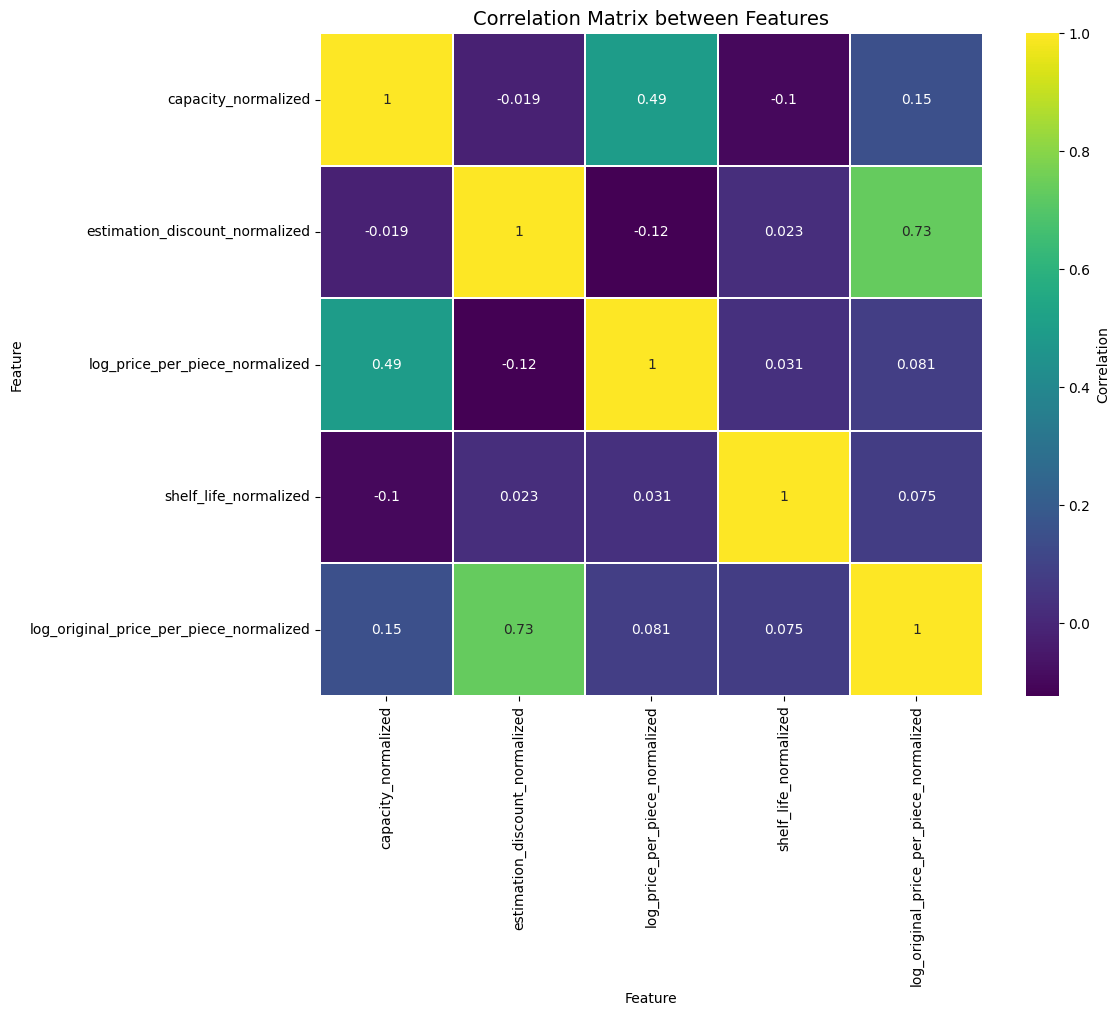

In [7]:
# Correlation matrix to measure the relationship between features using Pearson correlation

rel =  df_selected[features_temp].corr(method='pearson')
plt.figure(figsize=(12, 10))

sns.heatmap(rel, cmap="viridis", square=True, linewidths=0.3, cbar_kws={"label": "Correlation"}, annot = True)

plt.title("Correlation Matrix between Features", fontsize=14)
plt.xlabel("Feature")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [8]:
# Remove the features that have a high correlation (greater than 0.7) to avoid multicollinearity issues in clustering algorithms

features = ['capacity_normalized', 
            'estimation_discount_normalized',
            'log_price_per_piece_normalized',
            'shelf_life_normalized']

In [9]:
# Data splitting into historical product and new product using 80/20 split
from sklearn.model_selection import train_test_split

historical_df, new_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=False
)

historical_df['product_source'] = 'historical'
new_df['product_source'] = 'new'

print(f"Historical products: {len(historical_df)}")
print(f"New products: {len(new_df)}")

Historical products: 299
New products: 75


In [ ]:
# Clustering using BIRCH on historical products
from sklearn.cluster import Birch
from sklearn.metrics import silhouette_score, davies_bouldin_score

historical_df_brc = historical_df.copy()

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
birch_validity = []
for t in thresholds:
    brch_tmp = Birch(threshold=t, n_clusters=None, compute_labels=True)
    brch_tmp.fit(historical_df_brc[features])
    labels = brch_tmp.predict(historical_df_brc[features])
    
    n_unique = len(set(labels))
    if n_unique < 2:
        continue
    
    sil_brc = silhouette_score(historical_df_brc[features], labels)
    db_brc = davies_bouldin_score(historical_df_brc[features], labels)
    
    birch_validity.append({
        'threshold': t,
        'n_clusters': n_unique,
        'silhouette': sil_brc,
        'davies_bouldin': db_brc
    })

df_birch = pd.DataFrame(birch_validity)

# Select best threshold: as long as the silhoutte score is greater than 0.5 and davies_bouldin score is less than 0.5, select the threshold with the minimum cluster; otherwise max silhoutte and db as tie-breaker
if not df_birch.empty:
    df_birch_sorted = df_birch[(df_birch['silhouette'] > 0.5) & (df_birch['davies_bouldin'] < 0.5)].sort_values(by=['n_clusters'], ascending=True)
    if not df_birch_sorted.empty:
        best_threshold = df_birch_sorted.iloc[0]['threshold']
    else:
        # Fallback to the best overall threshold
        df_birch_sorted = df_birch.sort_values(by=['silhouette', 'davies_bouldin'], ascending=[False, True])
        best_threshold = df_birch_sorted.iloc[0]['threshold']
else:
    # Fallback to the best overall threshold
    df_birch_sorted = df_birch.sort_values(by=['silhouette', 'davies_bouldin'], ascending=[False, True])
    best_threshold = df_birch_sorted.iloc[0]['threshold']
print(f"Best BIRCH threshold: {best_threshold}")

# Refit BIRCH with the best threshold
brc = Birch(threshold=best_threshold, n_clusters=None, compute_labels=True)
brc.fit(historical_df_brc[features])
historical_labels_brc = brc.predict(historical_df_brc[features])

# Save cluster labels to the historical products
historical_clustered_brc = historical_df_brc.copy()
historical_clustered_brc['cluster'] = historical_labels_brc

historical_cluster_sizes = historical_clustered_brc['cluster'].value_counts()
historical_clustered_brc['cluster_size'] = historical_clustered_brc['cluster'].map(historical_cluster_sizes)
historical_clustered_brc['allocation_type'] = np.where(
    historical_clustered_brc['cluster_size'] > 1,
    'common allocation',
    'random allocation'
    )

print(f"Initial number of BIRCH subclusters: {len(brc.subcluster_centers_)}")
print(df_birch[['threshold', 'n_clusters', 'silhouette', 'davies_bouldin']])
print(f'Best threshold for BIRCH: {best_threshold}')
print(f'Best silhouette score for BIRCH: {df_birch_sorted.iloc[0]["silhouette"]:.4f}')

Best BIRCH threshold: 0.2
Initial number of BIRCH subclusters: 77
   threshold  n_clusters  silhouette  davies_bouldin
0        0.1         133    0.574158        0.263136
1        0.2          76    0.515772        0.455569
2        0.3          49    0.494347        0.530679
3        0.4          36    0.429422        0.621850
4        0.5          27    0.385345        0.787824
5        0.6          20    0.404682        0.707635
6        0.7          14    0.351324        0.767196
7        0.8          12    0.334192        0.862284
8        1.0           9    0.280805        0.856248
Best threshold for BIRCH: 0.2
Best silhouette score for BIRCH: 0.5158


In [11]:
historical_clustered_brc.head()

,title,category,price,brand,specification,query,original_price,original_price_checked,capacity,shelf_life,...,log_original_price_per_piece,shelf_life_normalized,log_price_per_piece_normalized,log_original_price_per_piece_normalized,estimation_discount_normalized,capacity_normalized,product_source,cluster,cluster_size,allocation_type
0,香滿室薰衣草地板清潔劑補充包,日用生活,85,毛寶,規格：1800g克x1x1bottle瓶,香滿室茶樹地板清潔劑補充包,95,1,1800.0,33.3,...,4.564348,-0.244091,-0.003226,0.669579,0.133389,0.287544,historical,20,19,common allocation
1,香滿室薰衣草地板清潔劑補充包,日用生活,85,毛寶,規格：1800g克x1x1bottle瓶,香滿室薰衣草地板清潔劑補充包,95,1,1800.0,33.3,...,4.564348,-0.244091,-0.003226,0.669579,0.133389,0.287544,historical,20,19,common allocation
2,白帥帥防蟑地板清潔劑-2000g,日用生活,169,白帥帥,規格：2000g克x1x1bottle瓶,白帥帥防蟑地板清潔劑,0,1,2000.0,33.3,...,0.000000,-0.244091,0.611067,-1.250157,-0.890440,0.439714,historical,1,3,common allocation
3,毛寶香滿室檀木馨香地板清潔劑,日用生活,109,毛寶,規格：2000g克x1x1bottle瓶,毛寶香滿室檀木馨香地板清潔劑,0,1,2000.0,33.3,...,0.000000,-0.244091,0.218650,-1.250157,-0.890440,0.439714,historical,21,8,common allocation
4,毛寶香滿室海洋微風清潔補充包,日用生活,85,毛寶,規格：1800g克x1x1bag袋,毛寶香滿室海洋微風地板清潔劑,95,1,1800.0,33.3,...,4.564348,-0.244091,-0.003226,0.669579,0.133389,0.287544,historical,20,19,common allocation


In [22]:
# Batch rule eligible for cluster assimilation: BIRCH

BATCH_SIZE = 20

current_catalog = historical_clustered_brc.copy()

for batch_number, start_idx in enumerate(range(0, len(new_df), BATCH_SIZE), start=1):
    batch_df = new_df.iloc[start_idx:start_idx + BATCH_SIZE].copy()
    batch_features = batch_df[features].copy()

    # Update the cluster structure with the incoming batch
    brc.partial_fit(batch_features)

    # Add the new products to the current catalog and recompute labels
    current_catalog = pd.concat([current_catalog, batch_df], ignore_index=True)
    current_catalog['cluster'] = brc.predict(current_catalog[features])

    cluster_sizes = current_catalog['cluster'].value_counts()
    current_catalog['cluster_size'] = current_catalog['cluster'].map(cluster_sizes)
    current_catalog['allocation_type'] = np.where(
        current_catalog['cluster_size'] > 1,
        'common allocation',
        'random allocation'
    )
    

current_catalog = current_catalog.sort_values(['allocation_type', 'cluster']).reset_index(drop=True)
current_catalog[['title', 'product_source', 'cluster', 'cluster_size', 'allocation_type']].head()

,title,product_source,cluster,cluster_size,allocation_type
0,家樂福超值地板清潔劑,historical,0,3,common allocation
1,妙管家中性有酵洗衣精-中性4000g,historical,0,3,common allocation
2,妙管家濃縮有酵洗衣精-抗菌4000g,historical,0,3,common allocation
3,白帥帥防蟑地板清潔劑-2000g,historical,1,4,common allocation
4,毛寶超強效萬用去污劑白柚清香,historical,1,4,common allocation


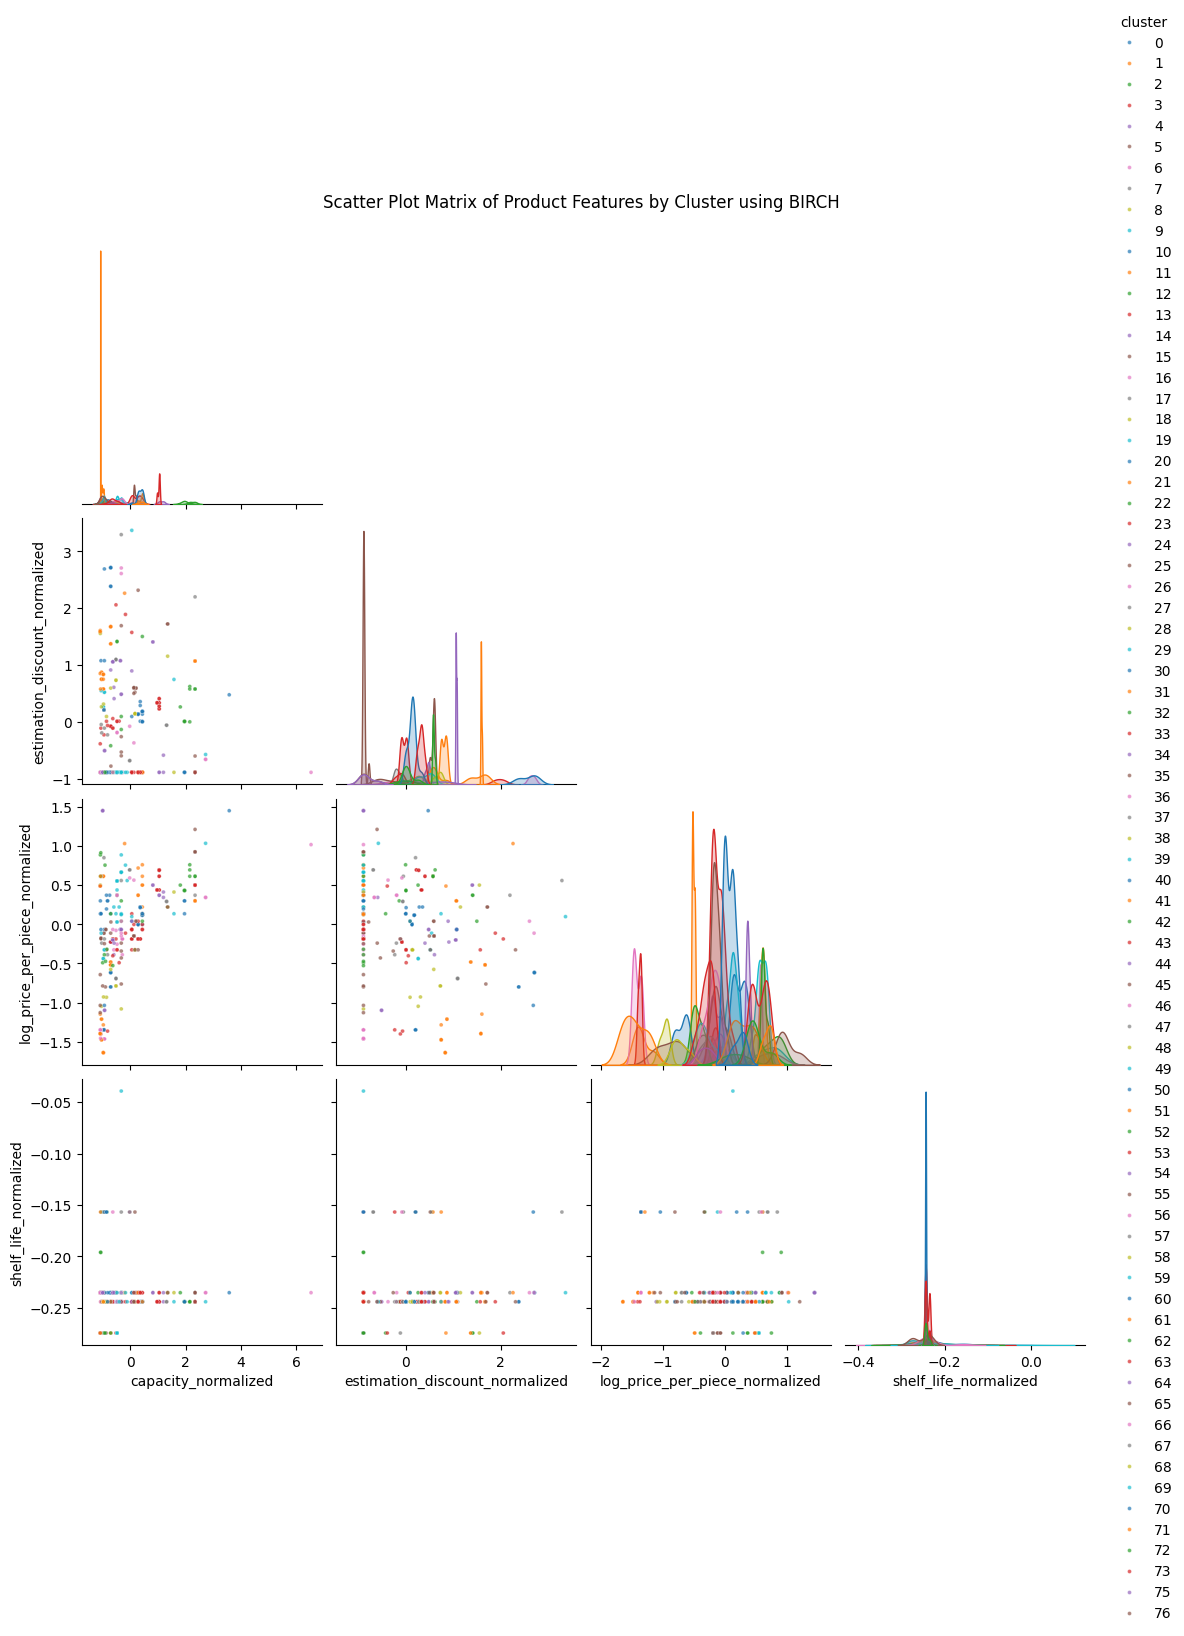

In [13]:
# BIRCH Scatter Plot Matrix
def scatterplot_matrix(df):
    '''
    Generate a scatter plot matrix for the given DataFrame.
    '''
    dims = historical_clustered_brc[features]
    g = sns.pairplot(
        data = historical_clustered_brc,
        vars = dims,
        hue = 'cluster',
        palette = 'tab10',
        corner = True,
        plot_kws={'s': 8, 'edgecolor': 'w', 'alpha': 0.7},
    )
    g.fig.set_size_inches(12, 12)
    g.fig.suptitle('Scatter Plot Matrix of Product Features by Cluster using BIRCH', y=1.02)
    for ax in g.axes.flatten():
        if ax:
            ax.xaxis.label.set_size(10)
            ax.yaxis.label.set_size(10)
    plt.show()

scatterplot_matrix(historical_clustered_brc)

In [14]:
# Optional: save the final BIRCH results
output_catalog_path = "D:/ITB/Thesis/Data/birchclustered.csv"
historical_clustered_brc.to_csv(output_catalog_path, index=False, encoding='utf-8-sig', sep=';')

print(output_catalog_path)

D:/ITB/Thesis/Data/birchclustered.csv


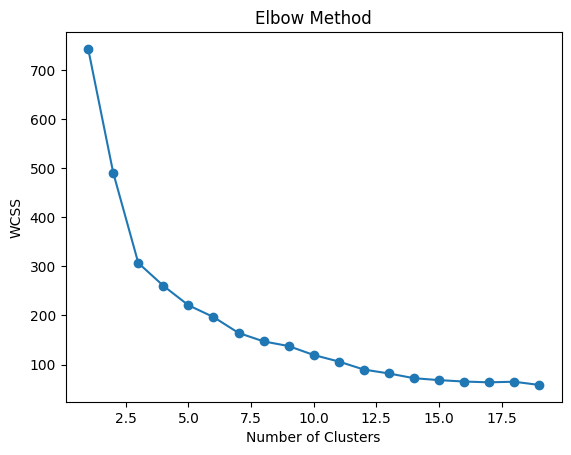

In [15]:
# Clustering using K-Means on historical products only

# Determine the number of clusters
# Elbow method: within-cluster sum of squares (WCSS), measures the variance within each clusters

from sklearn.cluster import KMeans

wcss = []
for k in range (1,20):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(historical_df[features])
    wcss.append(kmeans.inertia_)

#Plot the Elbow graph
plt.plot(range(1,20), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [16]:
# K-means clustering

historical_df_k = historical_df.copy()

# Candidate K values
k_values = list(range(2, 20))

# 1) Elbow on WCSS to get candidate range around the knee
wcss = []
for k in k_values:
    kmeans_tmp = KMeans(n_clusters=k, random_state=0)
    kmeans_tmp.fit(historical_df_k[features])
    wcss.append(kmeans_tmp.inertia_)

# Relative WCSS improvement from K-1 to K (for K >= 3 in this setup)
wcss_diff = np.diff(wcss)
relative_drop = np.abs(wcss_diff[1:] / wcss_diff[:-1])

# Knee proxy: first K where improvement falls below 50% of previous improvement
knee_threshold = 0.5
knee_candidates = np.where(relative_drop < knee_threshold)[0]

if len(knee_candidates) > 0:
    knee_k = k_values[knee_candidates[0] + 2]
else:
    # Fallback: if no clear knee, use middle of search space
    knee_k = int(np.median(k_values))

candidate_window = 1
candidate_k_values = [
    k for k in range(knee_k - candidate_window, knee_k + candidate_window)
    if k in k_values
]

# 2) Within candidate range, pick max silhouette (Euclidean for K-Means)
# 3) Use Davies-Bouldin as tie-breaker (lower is better)
from sklearn.metrics import silhouette_score, davies_bouldin_score

kmeans_clustering_validity = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(historical_df_k[features])
    labels_k = kmeans.labels_

    historical_clustered_k = historical_df_k.copy()
    historical_clustered_k['cluster'] = labels_k

    historical_cluster_sizes = historical_clustered_k['cluster'].value_counts()
    historical_clustered_k['cluster_size'] = historical_clustered_k['cluster'].map(historical_cluster_sizes)
    historical_clustered_k['allocation_type'] = np.where(
        historical_clustered_k['cluster_size'] > 1,
        'common allocation',
        'random allocation'
    )

    sil_score = silhouette_score(
        historical_clustered_k[features],
        historical_clustered_k['cluster'],
        metric='euclidean'
    )
    db_index = davies_bouldin_score(
        historical_clustered_k[features],
        historical_clustered_k['cluster']
    )

    kmeans_clustering_validity.append({
        'K': k,
        'Silhouette': sil_score,
        'Davies-Bouldin': db_index,
        'WCSS': kmeans.inertia_,
        'In_Elbow_Candidate_Range': k in candidate_k_values
    })

df_k = pd.DataFrame(kmeans_clustering_validity)

# Select the best K: as long as the silhouette score is greater than 0.5 and davies_bouldin score is less than 0.5, select the K with the maximum silhouette score; otherwise max silhouette and db as tie-breaker
selection_pool = df_k[df_k['K'].isin(candidate_k_values)].copy()
if selection_pool.empty:
    selection_pool = df_k.copy()

selection_pool = selection_pool.sort_values(
    by=['Silhouette', 'Davies-Bouldin'],
    ascending=[False, True]
)
best_row = selection_pool.iloc[0]

best_k = int(best_row['K'])
best_distance = 'euclidean'
best_silhouette = float(best_row['Silhouette'])

# Refit K-means with selected K
best_kmeans = KMeans(n_clusters=best_k, random_state=0).fit(historical_df_k[features])
historical_clustered_k_best = historical_df_k.copy()
historical_clustered_k_best['cluster'] = best_kmeans.labels_

cluster_sizes_best = historical_clustered_k_best['cluster'].value_counts()
historical_clustered_k_best['cluster_size'] = historical_clustered_k_best['cluster'].map(cluster_sizes_best)
historical_clustered_k_best['allocation_type'] = np.where(
    historical_clustered_k_best['cluster_size'] > 1,
    'common allocation',
    'random allocation'
 )

print(f"Elbow knee K (proxy): {knee_k}")
print(f"Candidate K range from elbow: {candidate_k_values}")
print(df_k[['K', 'WCSS', 'Silhouette', 'Davies-Bouldin']])
print(f"Best K: {best_k}")
print(f"Best distance metric: {best_distance}")
print(f"Best silhouette score: {best_silhouette:.4f}")

Elbow knee K (proxy): 4
Candidate K range from elbow: [3, 4]
     K        WCSS  Silhouette  Davies-Bouldin
0    2  490.740687    0.415636        0.931993
1    3  307.017754    0.400326        0.920517
2    4  260.534673    0.299627        1.086841
3    5  220.882423    0.314215        1.018436
4    6  196.855483    0.300043        1.075358
5    7  164.534389    0.320299        0.994323
6    8  147.239484    0.339716        0.957282
7    9  137.700045    0.338982        0.985853
8   10  119.508540    0.344615        0.897953
9   11  106.194447    0.356584        0.887227
10  12   89.858928    0.379399        0.846715
11  13   81.849534    0.400434        0.830790
12  14   72.242729    0.422157        0.813075
13  15   68.287632    0.424049        0.805920
14  16   65.372738    0.408734        0.823773
15  17   63.776409    0.397736        0.804063
16  18   64.982699    0.397263        0.801900
17  19   58.478988    0.399920        0.808592
Best K: 3
Best distance metric: euclidean
Best

In [24]:
# Batch rule eligible for cluster assimilation: K-Means

BATCH_SIZE = 20

current_catalog = historical_clustered_k.copy()

for batch_number, start_idx in enumerate(range(0, len(new_df), BATCH_SIZE), start=1):
    batch_df = new_df.iloc[start_idx:start_idx + BATCH_SIZE].copy()
    batch_features = batch_df[features].copy()

    # Add the new products to the current catalog and recompute labels
    current_catalog = pd.concat([current_catalog, batch_df], ignore_index=True)
    current_catalog['cluster'] = kmeans.predict(current_catalog[features])

    cluster_sizes = current_catalog['cluster'].value_counts()
    current_catalog['cluster_size'] = current_catalog['cluster'].map(cluster_sizes)
    current_catalog['allocation_type'] = np.where(
        current_catalog['cluster_size'] > 1,
        'common allocation',
        'random allocation'
    )

current_catalog = current_catalog.sort_values(['allocation_type', 'cluster']).reset_index(drop=True)
current_catalog[['title', 'product_source', 'cluster', 'cluster_size', 'allocation_type']].head(20)

,title,product_source,cluster,cluster_size,allocation_type
0,新威猛先生廚房檸檬噴槍,historical,0,24,common allocation
1,威猛先生去霉劑噴槍重裝特惠組,historical,0,24,common allocation
2,威猛先生浴室全效噴槍+重裝500gx2,historical,0,24,common allocation
3,威猛先生浴室全效噴槍+重裝500gx2,historical,0,24,common allocation
4,威猛先生強力去霉劑噴槍+重裝400g+400g,historical,0,24,common allocation
5,威猛先生強力去霉劑噴槍+重裝400g+400g,historical,0,24,common allocation
6,威猛先生去霉劑噴槍重裝特惠組,historical,0,24,common allocation
7,妙管家中性浴廁清潔劑-玫瑰花香-750g,historical,0,24,common allocation
8,妙管家馬桶芳香清潔劑-香水百合750g,historical,0,24,common allocation
9,潔霜芳香浴廁清潔劑--檸檬,historical,0,24,common allocation


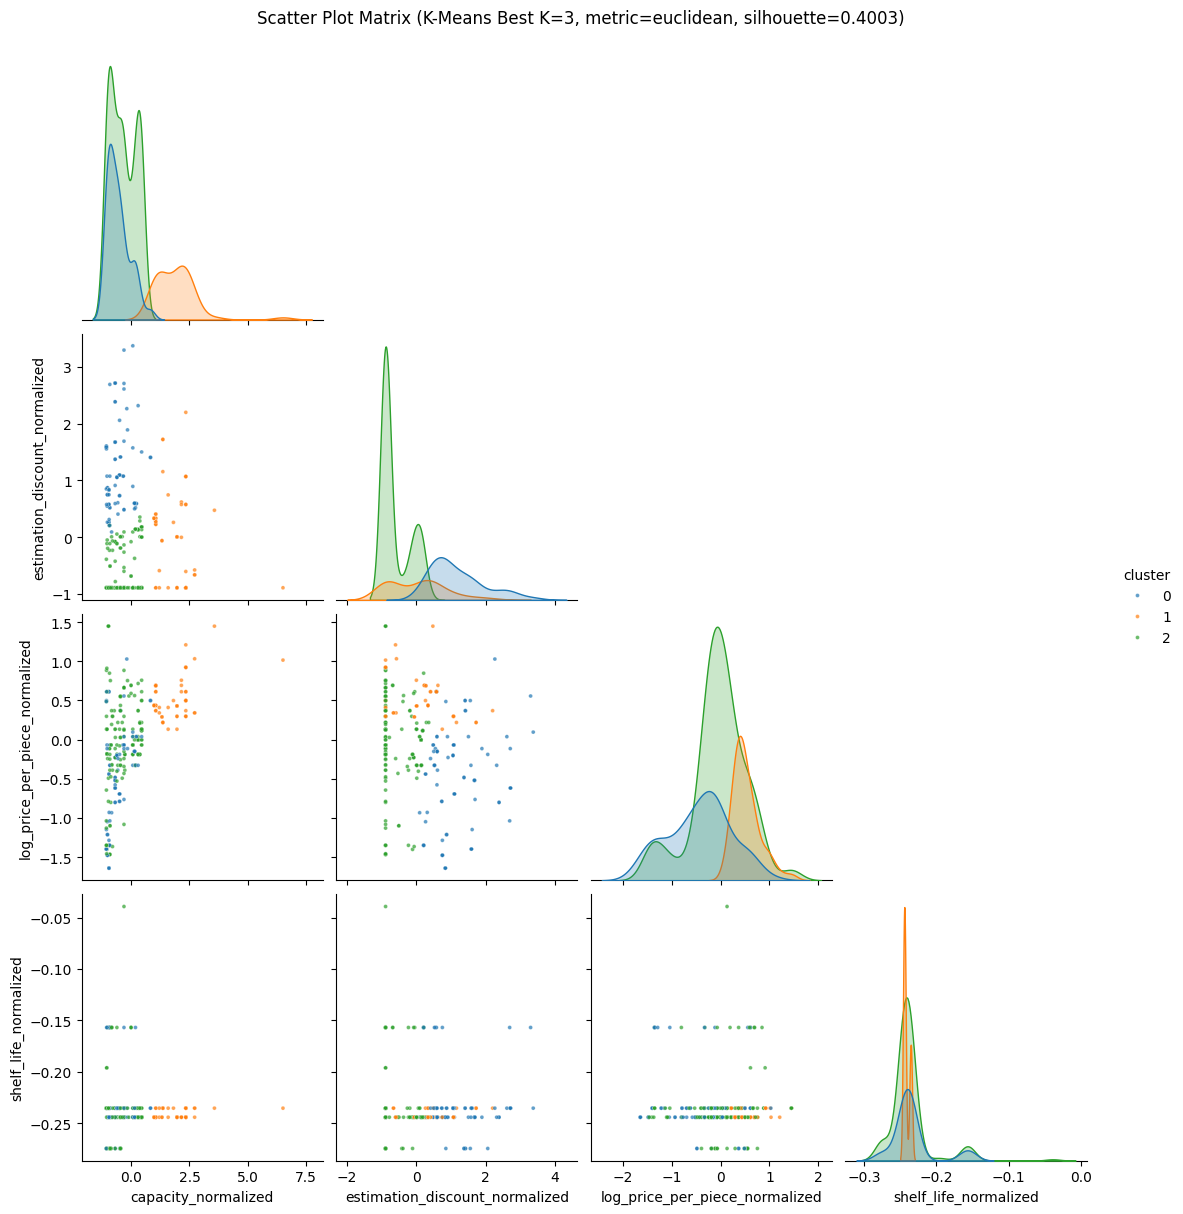

In [18]:
# Scatter Plot Matrix K-Means
def scatterplot_matrix_kmeans_best(df, feature_columns, best_k, best_distance, best_silhouette):
    '''
    Generate a scatter plot matrix for K-Means result with the best silhouette score.
    '''
    g = sns.pairplot(
        data=df,
        vars=feature_columns,
        hue='cluster',
        palette='tab10',
        corner=True,
        plot_kws={'s': 8, 'edgecolor': 'w', 'alpha': 0.7},
    )
    g.fig.set_size_inches(12, 12)
    g.fig.suptitle(
        f'Scatter Plot Matrix (K-Means Best K={best_k}, metric={best_distance}, silhouette={best_silhouette:.4f})',
        y=1.02
    )
    for ax in g.axes.flatten():
        if ax:
            ax.xaxis.label.set_size(10)
            ax.yaxis.label.set_size(10)
    plt.show()

scatterplot_matrix_kmeans_best(
    historical_clustered_k_best,
    features,
    best_k,
    best_distance,
    best_silhouette
 )

In [19]:
# Optional: save the final K-Means results (best silhouette K)
output_catalog_path = "D:/ITB/Thesis/Data/kmeansclustered.csv"
historical_clustered_k_best.to_csv(output_catalog_path, index=False, encoding='utf-8-sig', sep=';')

print(output_catalog_path)

D:/ITB/Thesis/Data/kmeansclustered.csv
